In [ ]:
import pandas as pd
import importlib
import utils.functions as functions 
importlib.reload(functions)
from utils.functions import *


import matplotlib.gridspec as gridspec
import seaborn as sns
import shutil 
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import tifffile as tiff
from matplotlib.animation import FuncAnimation, PillowWriter

from pathlib import Path
root_dir = Path(".")
print(root_dir)

from applefy_extensions.contrast_curves import ContrastFast
from applefy.detections.contrast import Contrast
from applefy.utils.photometry import AperturePhotometryMode
from applefy.statistics import TTest, gaussian_sigma_2_fpf, \
    fpf_2_gaussian_sigma

from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.positions import center_subpixel


.


## Training

In [ ]:
img = tiff.imread('/home/aosimul/noah/data/ghost_images/phase_screens/tiff_stg1/21.82_2026-06-10T13-54-47.943_0.tif')
img_array = np.array(img)
plt.imshow(np.log10( zoom_to_peak(img[0], 20))) 
plt.colorbar(label = 'log intensity')

In [ ]:
np.unravel_index(np.argmax(img[0], axis=None), img[0].shape)


In [ ]:
folder = '/home/aosimul/noah/data/ghost_images/phase_screens/tiff_stg1/'
frames = []
output_gif = f'{folder}animation.gif'

center = (101,93)
radius = 80

winds = [0.91575148, 1.03320503, 0.82179083, 1.17081484, 0.95867449]
randomState = np.random.RandomState(42) 
overlay = None

for i, windspeed in enumerate(windspeeds):

    tiff_files = tiff.imread(f'{folder}{windspeed}*.tif')[:15]

    wind = np.asarray(
        list(randomState.randint(25, 29, 9))
    ) * winds[i]

    mini = np.log10(tiff_files.min())
    maxi = np.log10(tiff_files.max())

    for j, file in enumerate(tiff_files):

        data = file[
            center[0]-radius:center[0]+radius+1,
            center[1]-radius:center[1]+radius+1
        ]

        # Log scale
        frame = np.log10(np.maximum(data, 1e-10))

        # Normalize to uint8
        frame -= mini
        frame /= maxi
        frame = (255 * frame).astype(np.uint8)

        img = Image.fromarray(frame).convert("RGB")

        # Build overlay once using the size of the first frame
        if j == 0:
            label = (
                f"Mean Windspeed = {windspeed}\n"
                f"{np.array2string(wind, 
                                   separator='\n', 
                                   formatter={'float_kind': lambda x: f'{x:.2f}'}
                                   )}"
            )
            overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
            draw = ImageDraw.Draw(overlay)
            draw.text(
                (5, 5),
                label,
                fill=(255, 255, 255, 255)
            )

        img = Image.alpha_composite(
            img.convert("RGBA"),
            overlay
        )

        frames.append(np.asarray(img))

imageio.mimsave(output_gif, frames, duration=0.001)

print(f"Saved GIF: {output_gif}")




In [ ]:
psf_stg1 = np.concatenate([tiff.imread(f'{folder}{windspeed}*.tif')[:7500] for windspeed in windspeeds])
np.save(f'results/datasets/psf_stg1_psf.npy', psf_stg1)

In [ ]:
psf_stg1     = np.load('results/datasets/psf_stg1_psf.npy')

plt.imshow(np.log10(np.mean(psf_stg1[:, 73:133, 64:124], axis = 0)))
plt.colorbar()
plt.title(f'Mean PSF over {np.shape(psf_stg1)[0]*0.005/60:.1f}min \nFWHM = {calculate_fwhm(np.mean(psf_stg1, axis = 0)):.2f}pix')
plt.show()

plt.figure(figsize=(20,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10(np.mean(psf_stg1[7500*(i-1):7500*i, 73:133, 64:124], axis = 0)), vmin = 2)
    plt.colorbar(fraction = 0.04)
    plt.title(f'Mean PSF over {7500*0.005:.1f}s \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm(np.mean(psf_stg1[7500*(i-1):7500*i, :, :], axis = 0)):.2f}pix')
plt.show()

plt.figure(figsize=(20,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10((psf_stg1[7500*i -1, 73:133, 64:124])), vmin = 2)
    plt.colorbar(fraction = 0.04)
    plt.title(f'Single PSF \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm((psf_stg1[7500*i -1, :, :])):.2f}pix')
plt.show()

## Load and View Images

### Download

In [ ]:
windspeeds = [21.82, 24.32,25.46, 27.44, 31.09]


In [ ]:
from skimage.registration import phase_cross_correlation

def estimate_center(stack, nframes=1000, upsample_factor=1000,
                    max_iter=100, tol=1e-3):
    """
    Estimate the center of a stack from the median of the first nframes
    using iterative 180° rotational phase cross-correlation.

    Returns
    -------
    yc, xc : float
        Subpixel center coordinates.
    """

    ref = np.median(stack[:nframes], axis=0)

    ny, nx = ref.shape
    yc = (ny - 1) / 2
    xc = (nx - 1) / 2

    for _ in range(max_iter):

        half = int(min(
            yc,
            xc,
            ny - 1 - yc,
            nx - 1 - xc
        ))

        y = int(round(yc))
        x = int(round(xc))

        sub = ref[y-half:y+half+1,
                  x-half:x+half+1]

        rot = np.rot90(sub, 2)

        shift, _, _ = phase_cross_correlation(
            sub,
            rot,
            upsample_factor=upsample_factor
        )

        dy, dx = shift / 2

        yc += dy
        xc += dx

        if np.hypot(dy, dx) < tol:
            print(f"Center converged after {_+1} iterations.")
            break

    return (yc, xc)

def crop_stack(stack, 
               coords = None,
               radius = None
               ):
    """
    Crop every frame to the largest odd square centered on (yc, xc).
    """

    if coords is None:
        yc, xc = estimate_center(stack)
    
    else:
        yc, xc = coords
    
    ny, nx = stack.shape[1:]

    if radius is None:
        half = int(min(
            yc,
            xc,
            ny - 1 - yc,
            nx - 1 - xc
        ))
    else:
        half = radius
        
    yc = int(round(yc))
    xc = int(round(xc))

    return stack[
        :,
        yc-half:yc+half+1,
        xc-half:xc+half+1
    ]

In [ ]:
# DOWNLOAD TIFF

folder      = '/home/aosimul/noah/data/ghost_images/phase_screens/tiff_4ms/'
sc_img      = np.concatenate([tiff.imread(sorted(glob.glob(f'{folder}{windspeed}_stg2_int*.tif')))[:9375] for windspeed in windspeeds])
sc_img_int  = sc_img.astype(np.float32) / 65535
sc_img      = np.concatenate([tiff.imread(sorted(glob.glob(f'{folder}{windspeed}_stg2_pred*.tif')))[:9375] for windspeed in windspeeds])
sc_img_pred = sc_img.astype(np.float32) / 65535

#center - assume centre is consistent throughout (i checked before)
# coords_max1 = (np.unravel_index(np.argmax(sc_img_int[0], axis=None), sc_img_int[0].shape))
# coords_max2 = (np.unravel_index(np.argmax(sc_img_pred[0], axis=None), sc_img_pred[0].shape))
# coords_max  = max(coords_max1, coords_max2)
# Large_rad   = min(coords_max)
# sc_img_pred = sc_img_pred[:, coords_max[0]-Large_rad:coords_max[0]+Large_rad+1, coords_max[1]-Large_rad:coords_max[1]+Large_rad+1]
# sc_img_int  = sc_img_int[:, coords_max[0]-Large_rad:coords_max[0]+Large_rad+1, coords_max[1]-Large_rad:coords_max[1]+Large_rad+1]
sc_img_int = crop_stack(sc_img_int, radius = 92)
sc_img_pred = crop_stack(sc_img_pred, radius = 92)
                           
print(sc_img_pred.shape, sc_img_int.shape)
np.save(f'/home/aosimul/noah/data/ghost_images/4ms/stg2_int.npy', sc_img_int)
np.save(f'/home/aosimul/noah/data/ghost_images/4ms/stg2_pred.npy', sc_img_pred)

In [ ]:
from photutils.centroids import (centroid_1dg, centroid_2dg,
                                 centroid_com, centroid_quadratic)
from scipy.ndimage import center_of_mass, gaussian_filter
dit_science = 4e-3  #s
dit_psf     = 10    #s
pixel_size  = 0.005 #arcsec
LambdaD     = 4     #pixels
n_psf       = round(dit_psf/dit_science)

print('scipy com, centroid_com, centroid_1dg, centroid_2dg, centroid_quadratic')
for i in range(2):
    print(np.round(np.array(center_of_mass(sc_img_int[i]))).astype(int), (np.round(np.array(centroid_com(sc_img_int[i]))).astype(int)), (np.round(np.array(centroid_1dg(sc_img_int[i]))).astype(int)), (np.round(np.array(centroid_2dg(sc_img_int[i]))).astype(int)), (np.round(np.array(centroid_quadratic(sc_img_int[i]))).astype(int)))
    print(np.round(np.array(center_of_mass(sc_img_int[-1-i]))).astype(int), (np.round(np.array(centroid_com(sc_img_int[-1-i]))).astype(int)), (np.round(np.array(centroid_1dg(sc_img_int[-1-i]))).astype(int)), (np.round(np.array(centroid_2dg(sc_img_int[-1-i]))).astype(int)), (np.round(np.array(centroid_quadratic(sc_img_int[-1-i]))).astype(int)))
# coords_max1 = (np.unravel_index(np.argmax(sc_img_int[0], axis=None), sc_img_int[0].shape))
# coords_max2 = (np.unravel_index(np.argmax(sc_img_pred[0], axis=None), sc_img_pred[0].shape))
print((np.round(np.array(center_of_mass(np.sum(sc_img_int[:n_psf],  axis = 0)))).astype(int)), (np.round(np.array(centroid_com(np.sum(sc_img_int[:n_psf],  axis = 0)))).astype(int)), (np.round(np.array(centroid_1dg(np.sum(sc_img_int[:n_psf],  axis = 0)))).astype(int)), (np.round(np.array(centroid_2dg(np.sum(sc_img_int[:n_psf],  axis = 0)))).astype(int)), (np.round(np.array(centroid_quadratic(np.sum(sc_img_int[:n_psf],  axis = 0)))).astype(int)))
smooth = gaussian_filter(np.sum(sc_img_int[:n_psf],  axis = 0), 1)    
print(np.round(np.array(center_of_mass(smooth))).astype(int), (np.round(np.array(centroid_com(smooth))).astype(int)), (np.round(np.array(centroid_1dg(smooth))).astype(int)), (np.round(np.array(centroid_2dg(smooth))).astype(int)), (np.round(np.array(centroid_quadratic(smooth))).astype(int)))


In [ ]:
smooth = gaussian_filter(np.sum(sc_img_int[:n_psf],  axis = 0), 50)    
print(np.round(np.array(center_of_mass(smooth))).astype(int), (np.round(np.array(centroid_com(smooth))).astype(int)), (np.round(np.array(centroid_1dg(smooth))).astype(int)), (np.round(np.array(centroid_2dg(smooth))).astype(int)), (np.round(np.array(centroid_quadratic(smooth))).astype(int)))


In [ ]:
#sc_img_int -= np.median(sc_img_int)
yc, xc = estimate_center(sc_img_int, nframes=1000, max_iter=100,upsample_factor=100, tol=1e-3)
print(f"Estimated center: (yc, xc) = ({yc:.2f}, {xc:.2f})")
yc, xc = estimate_center(sc_img_int, nframes=1000, max_iter=100, upsample_factor=1000, tol=1e-3)
print(f"Estimated center: (yc, xc) = ({yc:.2f}, {xc:.2f})")
yc, xc = estimate_center(sc_img_int, nframes=1000, max_iter=100, upsample_factor=10000, tol=1e-3)
print(f"Estimated center: (yc, xc) = ({yc:.2f}, {xc:.2f})")
#cropped_stack = crop_stack(sc_img_int, coords=(yc, xc))

In [ ]:
coords = np.array([
    np.unravel_index(np.argmax(frame), frame.shape)
    for frame in sc_img_int
])

mean_coord = coords.mean(axis=0)

print(mean_coord)  # (y_mean, x_mean)

coords = np.array([
    np.unravel_index(np.argmax(frame), frame.shape)
    for frame in sc_img_pred
])

mean_coord = coords.mean(axis=0)

print(mean_coord)  # (y_mean, x_mean)

### Load Saved Frames

In [7]:
# LOAD IMAGES
# 
##psf_stg1 = np.concatenate([tiff.imread(f'{folder}{windspeed}*.tif')[:7500] for windspeed in windspeeds])
#np.save(f'results/datasets/psf_stg1_psf.npy', psf_stg1)

frame_rate  = 1/400 #s
dit_science = 4e-3  #s
dit_psf     = 10    #s
pixel_size  = 0.005 #arcsec
LambdaD     = 4     #pixels
n_psf       = round(dit_psf/dit_science)
radius      = 20
sc_img_int  = np.load('/home/aosimul/noah/data/ghost_images/4ms/stg2_int.npy')
sc_img_pred = np.load('/home/aosimul/noah/data/ghost_images/4ms/stg2_pred.npy')
psf_int     = np.load('/home/aosimul/noah/data/ghost_images/4ms/psf_int.npy')
psf_pred    = np.load('/home/aosimul/noah/data/ghost_images/4ms/psf_pred.npy')
# np.save(f'/home/aosimul/noah/data/ghost_images/4ms/psf_int.npy', psf_int)
# np.save(f'/home/aosimul/noah/data/ghost_images/4ms/psf_pred.npy', psf_pred)

# sc_img_int  = sc_img_int[:, ]
# psf_int     = np.sum(sc_img_int[:n_psf],  axis = 0)
# psf_int     = zoom_to_peak(psf_int, radius)
# psf_pred    = np.sum(sc_img_pred[:n_psf], axis = 0)
# psf_pred    = zoom_to_peak(psf_pred, radius)

In [3]:
# OPTIONAL: INCREASE INTEGRATION TIME
binning = 25
sc_img_int     = sc_img_int.reshape(int(sc_img_int.shape[0]/binning), binning, *sc_img_int.shape[1:]).sum(axis=1)
sc_img_pred    = sc_img_pred.reshape(int(sc_img_pred.shape[0]/binning), binning, *sc_img_pred.shape[1:]).sum(axis=1)
dit_science    = dit_science*binning

In [ ]:
psf_stg1     = sc_img_int
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(np.mean(psf_stg1[:, 50:135, 50:135], axis = 0)))
plt.title('classic AO')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(np.mean(sc_img_pred[:, 50:135, 50:135], axis = 0)))
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.title('predictive AO')
plt.suptitle(f'        Mean PSF over {np.shape(psf_stg1)[0]*0.005/60:.1f}min')
plt.show()

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(np.mean(psf_stg1[:, 50:135, 50:135], axis = 0)))
plt.title('classic AO')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(np.mean(sc_img_pred[:, 50:135, 50:135], axis = 0)))
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.title('predictive AO')
plt.suptitle(f'        Mean PSF over {np.shape(psf_stg1)[0]*0.005/60:.1f}min')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10(np.mean(psf_stg1[9375*(i-1):9375*i,  50:135, 50:135], axis = 0)), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'        Mean PSF over {9375*0.004:.1f}s \nWindspeed = {windspeeds[i-1]}m/s \n        FWHM = {calculate_fwhm(np.mean(psf_stg1[9375*(i-1):9375*i, :, :], axis = 0)):.2f}pix')
plt.suptitle('classic AO')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10(np.mean(sc_img_pred[9375*(i-1):9375*i, 50:135, 50:135], axis = 0)), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'Mean PSF over {9375*0.004:.1f}s \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm(np.mean(sc_img_pred[9375*(i-1):9375*i, :, :], axis = 0)):.2f}pix')
plt.suptitle('predictive AO')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10((psf_stg1[9375*i -1, 50:135, 50:135])), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'Single PSF \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm((psf_stg1[9375*i -1, :, :])):.2f}pix')
plt.suptitle('classic AO')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10((sc_img_pred[9375*i -1, 50:135, 50:135])), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'Single PSF \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm((sc_img_pred[9375*i -1, :, :])):.2f}pix')
plt.suptitle('predictive AO')
plt.show()

In [ ]:
# VIEW

# plt.figure(figsize=(11,4))
# plt.subplot(1,2,1)
# plt.imshow(np.log10(psf_int))
# plt.title('classic AO psf')
# plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
# plt.subplot(1,2,2)
# plt.imshow(np.log10(psf_pred))
# plt.title('predictive AO psf')
# plt.colorbar(fraction =0.04)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(sc_img_int[0]), vmin = -3)
plt.title('HC classic AO sc img')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(sc_img_pred[0]), vmin = -3)
plt.title('HC predictive AO sc img')
plt.colorbar(fraction =0.04)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(sc_img_int[0]) - np.log10(sc_img_pred[0, :, :]))
plt.title('classic AO - predictive AO')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(sc_img_int[0]) - np.log10(sc_img_pred[0, :, :]), vmax = 0.15, vmin = -0.05)
plt.title('High Contrast Scale')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')


## Generate Comtrast Curves

### Create Fake Planets

In [ ]:
# CREATE DATASETS
datasets = {
    "int": {
        "psf"           : psf_int,
        "sci_img"       : sc_img_int2,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,          #s of integration time
        "dit_science"   : dit_science2,     #s = 10 phase screens at 0.001s each
    },

    "pred": {
        "psf"           : psf_pred,
        "sci_img"       : sc_img_pred2,
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : dit_psf,          #s of integration time
        "dit_science"   : dit_science2,  
    },
}

algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

curves = {}

#FILL
#-----------
# fake planet brightness
flux_ratio_mag          = 16
num_fake_planets        = 3
components              = [5, 10, 20, 50, 75, 100] 
scaling_factor          = 1.0  # A factor to account e.g. for ND filters
angles                  = np.linspace(0, 30, np.shape(sc_img_int)[0])   #parang[::10]
angles                  = np.deg2rad(angles)
flux_ratio              = mag2flux_ratio(flux_ratio_mag)
name                    = 'GHOST_no_coro'
separation              = 1
max_separation          = 0.8                                           #in fraction of total image radius
approx_svd_trunc        = round(np.shape(sc_img_int)[0] / 3)
device                  = 'cuda'                                        #'cpu'
#-----------

for dataset_name, dataset in datasets.items():
    for algo_name, alg in algorithms.items():

        path = f"results/contrast_curves/{name}_{dataset_name}_{algo_name}"
        if not os.path.exists(path):
            os.makedirs(path)
            
        contrast_instance = Contrast(
            science_sequence    =dataset["sci_img"],
            psf_template        =dataset["psf"],
            parang_rad          =angles,
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            scaling_factor      =scaling_factor, # A factor to account e.g. for ND filters
            checkpoint_dir      =root_dir / Path(path)
            )
        seps =  None if separation == None else np.arange(0, round(center_subpixel(dataset["sci_img"][0])[0] * max_separation), dataset["fwhm"]* separation)[1:]
        contrast_instance = fake_planet_experiment(contrast_instance, flux_ratio, num_fake_planets, components, version = alg,
        separations = seps, 
        approx_svd = approx_svd_trunc if approx_svd_trunc else -1,
        device= device)
        curves[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=pixel_size,  photometry = 'AS', test = 't-test')

    # save the contrast curves in a single dataframe
    (curve, err) = curves[(dataset_name, "PCAD")]
    (curve_cadi, err_cadi) = curves[(dataset_name, "CADI")]

    curves[(dataset_name, "merged")] = (
        pd.merge(curve, curve_cadi, left_index= True, right_index=True, how="inner"),
        pd.merge(err, err_cadi, left_index= True, right_index=True, how="inner")
    )

In [ ]:
# GPU BULLSHIT

import gc
import torch
import psutil, os

print("Allocated:",
      torch.cuda.memory_allocated()/1024**3, "GB")

print("Reserved:",
      torch.cuda.memory_reserved()/1024**3, "GB")



process = psutil.Process(os.getpid())

print("CPU RAM:",
    process.memory_info().rss / 1024**3,
    "GB"
)

total = 0

for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj):
            total += obj.numel() * obj.element_size()
    except Exception:
        pass

print(total / 1024**3, "GB in live tensors")


### From Folders

In [ ]:
# CREATE CURVES FROM CHECKPOINT DIR

datasets = {
    "int": {
        "psf"           : psf_int,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,      #s of integration time
        "dit_science"   : dit_science,            #s = 10 phase screens at 0.001s each
    },

    "pred": {
        "psf"           : psf_pred,
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : dit_psf,      #s of integration time
        "dit_science"   : dit_science,  
    },
    
}


algorithms = {
    "PCAD": "PCAD",
 #   "CADI": "CADI",
}

curves = {}

#FILL
#-----------
name                    = 'pipeline_ADI'
#-----------


for dataset_name, dataset in datasets.items():
    for algo_name, device in algorithms.items():

        path = f"/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/{name}_{dataset_name}_{algo_name}"
        #path = f"/home/aosimul/noah/results/contrast_curves/{name}_{dataset_name}_{algo_name}"
        
        contrast_instance = Contrast.create_from_checkpoint_dir(
            psf_template        =dataset["psf"],
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            checkpoint_dir      =root_dir / Path(path)
            )

        curves[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=pixel_size,  photometry = 'AS', test = 't-test')


    # save the contrast curves in a single dataframe
#     (curve, err) = curves[(dataset_name, "PCAD")]
#    # (curve_cadi, err_cadi) = curves[(dataset_name, "CADI")]

#     curves[(dataset_name, "merged")] = (
#         pd.merge(curve, curve_cadi, left_index= True, right_index=True, how="inner"),
#         pd.merge(err, err_cadi, left_index= True, right_index=True, how="inner")
#    )
    
pipeline_ADI_gram = curves.copy()

In [ ]:
# MAKE PLOTS
rangey      = (16, 4)
name = 'Pipeline Comparison - gram method'
components              = [5, 10, 20, 50, 75, 100] #[10, 50, 100, 150]
curves = pipeline_ADI_gram
for dataset_name, dataset in datasets.items():
    contrast, err = curves[(dataset_name, "PCAD")]
    plot_contrast_curves(contrast, err, rangey, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name} AO"), x_axis = (1/LambdaD/pixel_size), x_axis_label= r"Separation [$\lambda$/D]")
    #plt.savefig(f'{dataset_name}_{name}.png')

plot_best_PCA_number([curves[("int", "PCAD")][0], curves[("pred", "PCAD")][0]], components, ['Classic AO', 'Predictive AO'])
#plt.savefig(f'PCA_{name}.png')

In [ ]:
folder = '/home/aosimul/noah/results/contrast_curves/test2'
create_pca_gif(
    folder,
    components,
    output_gif="pred_newlyot_safe.gif",
    duration=0.5,
)

In [ ]:
# MAKE PLOTS
rangey = (13, 0)
name = 'GHOST non-coro Comparison - gram method'
components              = [5, 10, 20, 50, 75, 100] 

for dataset_name, dataset in datasets.items():
    contrast1, err1 = GHOST_no_coro[(dataset_name, "merged")]
    contrast2, err2 = pipeline_ADI[(dataset_name, "merged")]


    comparison(
        contrast1,
        err1,
        contrast2,
        err2,
        title=f"20ms DIT, 9735 frames vs 4ms, {9375*5} frames: {dataset_name}",
        #x_axis=(1/LambdaD/pixel_size),
        cmap = 'winter'
    )

In [ ]:
# MAKE PLOTS
rangey = (13, 0)
name = 'Pipeline Comparison - gram vs lowrank method'
components              = [5, 10, 20, 50, 75, 100] 

for dataset_name, dataset in datasets.items():
    contrast1, err1 = pipeline_ADI[(dataset_name, "merged")]
    contrast2, err2 = pipeline_ADI_gram[(dataset_name, "merged")]


    comparison(
        contrast1,
        err1,
        contrast2,
        err2,
        title=f"20ms DIT, 9735 frames vs 4ms, {9375*5} frames: {dataset_name}",
        #x_axis=(1/LambdaD/pixel_size),
        cmap = 'winter'
    )

## Phase Screens

In [ ]:
arr = np.load('/home/aosimul/noah/data/ghost_images/test/5seeing/SLM_phase_screens_19.81_1.mat.npy')

In [ ]:
print(arr.shape)
print(arr.dtype)
print(arr.nbytes/1024**2, "MB")

In [ ]:
data = arr.astype(np.uint8)
print(data.shape)
print(data.dtype)
print(data.nbytes/1024**2, "MB")

In [ ]:
zero_padded = np.zeros((1920,1152, data.shape[0]), dtype=np.uint8)
zero_padded[384:384+1152,:,:] = data.T

print(zero_padded.shape)
print(zero_padded.dtype)
print(zero_padded.nbytes/1024**2, "MB")

In [ ]:
print(os.path.getsize('/home/aosimul/noah/data/ghost_images/test/5seeing/SLM_phase_screens_19.81_1.mat.npy')/1024**2, "MB")
print(os.path.getsize('/home/aosimul/noah/data/ghost_images/test/5seeing/SLM_phase_screens_19.81_1.mat')/1024**2, "MB")

# Compute Contrast Grid

## Tutorial

### From Applefy Documentation

In [4]:
root_dir_tut = Path("/home/aosimul/noah/results")
dataset_config = {'file_path': root_dir_tut / Path('datasets/betapic_naco_lp_LR.hdf5'),
                  'stack_key': "science_no_planet",
                  'psf_template_key': "psf_template",
                  'parang_key': 'header_science_no_planet/PARANG',
                  'dit_psf_template': 0.02019, # Diameter in pixel
                  'fwhm_size' : 4.2,
                  'dit_science': 0.2}

# we need the psf template for contrast calculation
science_data, angles, raw_psf_template_data = load_adi_data(
    #root_dir_tut/
    dataset_config["file_path"],
    data_tag=dataset_config["stack_key"],
    psf_template_tag=dataset_config["psf_template_key"],
    para_tag=dataset_config["parang_key"])

dit_psf_template = dataset_config["dit_psf_template"]
dit_science = dataset_config["dit_science"]
fwhm = dataset_config["fwhm_size"]

psf_template = raw_psf_template_data[82:-82, 82:-82]
science_data = science_data[:, 55:-55, 55:-55]

In [5]:
output_path = root_dir_tut / Path("tutorial/contrast_grid")

if output_path.exists():
    shutil.rmtree(output_path)
    print(f"Removed existing directory to avoid overwrites: {output_path}.")

output_path.mkdir(
    parents=True,
    exist_ok=True
)

contrast_instance = Contrast(
    science_sequence=science_data,
    psf_template=psf_template,
    parang_rad=angles,
    psf_fwhm_radius=fwhm / 2,
    dit_psf_template=dit_psf_template,
    dit_science=dit_science,
    checkpoint_dir=output_path )

# fake planet brightness
flux_ratios_mag = np.linspace(5,15, 2)
flux_ratios = mag2flux_ratio(flux_ratios_mag)

print("Brightness of fake planets in mag: " + str(flux_ratios_mag))
print("Planet-to-star flux ratio: " + str(flux_ratios))

num_fake_planets = 2

# contrast_instance.design_fake_planet_experiments(
#     flux_ratios=flux_ratios,
#     num_planets=num_fake_planets,
#     overwrite=True)

components = [5, 10, 20, 30, 50]

Removed existing directory to avoid overwrites: /home/aosimul/noah/results/tutorial/contrast_grid.
Brightness of fake planets in mag: [ 5. 15.]
Planet-to-star flux ratio: [1.e-02 1.e-06]


In [6]:
from applefy.wrappers.vip import MultiComponentPCAvip
kwargs={'imlib':'skimage', 'interpolation':'biquintic', "nproc":None, 'verbose':False} # for speed improvement
algorithm_function = MultiComponentPCAvip(
    num_pcas=components,
    kwarg=kwargs)


contrast_instance.design_fake_planet_experiments(
    flux_ratios=flux_ratios,
    num_planets=num_fake_planets,
    overwrite=True)

from applefy.wrappers.pynpoint import MultiComponentPCAPynPoint
algorithm_function = MultiComponentPCAPynPoint(
    num_pcas=components,
    scratch_dir=contrast_instance.scratch_dir,
    num_cpus_pynpoint=1)

contrast_instance.run_fake_planet_experiments(
    algorithm_function=algorithm_function,
    num_parallel=1)

Running fake planet experiments...

 21%|██        | 7/33 [00:38<01:57,  4.52s/it]

KeyboardInterrupt: 

In [ ]:
# Use apertures pixel values
photometry_mode_planet = AperturePhotometryMode(
    "AS", # or "ASS"
    psf_fwhm_radius=fwhm/2,
    search_area=0.5)

photometry_mode_noise = AperturePhotometryMode(
    "AS",
    psf_fwhm_radius=fwhm/2)

contrast_instance.prepare_contrast_results(
    photometry_mode_planet=photometry_mode_planet,
    photometry_mode_noise=photometry_mode_noise)

statistical_test = TTest()

contrast_curves_grid, contrast_grids = contrast_instance.compute_contrast_grids(
    statistical_test=statistical_test,
    num_cores=5,
    confidence_level_fpf=gaussian_sigma_2_fpf(5),
    num_rot_iter=20,
    safety_margin=5.0,
    pixel_scale=0.02718)

In [ ]:
rangey = (11, 8)
limx = (0.3, 0.95)
plot_contrast_curves2(contrast_curves_grid, rangey, lim_x = limx, cmap = 'magma', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\nTurorial & my function"))

In [ ]:
components = [5, 10, 20, 30, 50]
folder = f'/home/aosimul/noah/results/tutorial/contrast_grid'

create_pca_gif(
    folder,
    components,
    output_gif=f"/home/aosimul/noah/results/animations/Tutorial_pca_grid_.gif",
    duration=0.5)

### My functions

In [ ]:
# Compare to using my function:
separation              = 1
max_separation          = 1   
seps =  None if separation == None else np.arange(0, round(center_subpixel(science_data[0])[0] * max_separation), fwhm* separation)[1:]
       
contrast_instance = fake_planet_experiment(contrast_instance, flux_ratios, num_fake_planets, components, version = 'PCAD', separations=seps)
contrast_curves_grid, contrast_grids = compute_contrast_curves(contrast_instance, fwhm, pixel_scale=0.02718,  photometry = 'AS', test = 't-test', grid = True)
        

In [ ]:
rangey = (11, 8)
limx = (0.3, 0.95)
plot_contrast_curves2(contrast_curves_grid, rangey, lim_x = limx, cmap = 'magma', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\nTurorial & my function + seps"))
#plt.savefig(f'/home/aosimul/noah/results/animations/Tutorial_ccfromgrid_myfunc.png')
components = [5, 10, 20, 30, 50]
folder = f'/home/aosimul/noah/results/tutorial/contrast_grid'

create_pca_gif(
    folder,
    components,
    output_gif=f"/home/aosimul/noah/results/animations/Tutorial_pca_ccfromgrid_myfunc.gif",
    duration=0.5)

In [ ]:
# Compare to using my function:
separation              = 1
max_separation          = 1   
seps =  None if separation == None else np.arange(0, round(center_subpixel(science_data[0])[0] * max_separation), fwhm* separation)[1:]
       
contrast_instance = fake_planet_experiment(contrast_instance, flux_ratios, num_fake_planets, components, version = 'CADI',)
contrast_curves_grid, contrast_grids = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=0.02718,  photometry = 'AS', test = 't-test', grid = True)
        


In [ ]:
rangey = (20, 2)
limx = (0.3, 0.95)
plot_contrast_curves2(contrast_curves_grid, rangey, lim_x = limx, cmap = 'magma', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\nTurorial & my function & CADI"))
#plt.savefig(f'/home/aosimul/noah/results/animations/Tutorial_ccfromgrid_myfunc.png')
components = None
folder = f'/home/aosimul/noah/results/tutorial/contrast_grid'

create_pca_gif(
    folder,
    components,
    output_gif=f"/home/aosimul/noah/results/animations/Tutorial_pca_ccfromgrid_myfunc_CADI.gif",
    duration=0.5)

### Fast Contrast

In [2]:
root_dir_tut = Path("/home/aosimul/noah/results")
dataset_config = {'file_path': root_dir_tut / Path('datasets/betapic_naco_lp_LR.hdf5'),
                  'stack_key': "science_no_planet",
                  'psf_template_key': "psf_template",
                  'parang_key': 'header_science_no_planet/PARANG',
                  'dit_psf_template': 0.02019, # Diameter in pixel
                  'fwhm_size' : 4.2,
                  'dit_science': 0.2}

# we need the psf template for contrast calculation
science_data, angles, raw_psf_template_data = load_adi_data(
    #root_dir_tut/
    dataset_config["file_path"],
    data_tag=dataset_config["stack_key"],
    psf_template_tag=dataset_config["psf_template_key"],
    para_tag=dataset_config["parang_key"])

dit_psf_template = dataset_config["dit_psf_template"]
dit_science = dataset_config["dit_science"]
fwhm = dataset_config["fwhm_size"]

psf_template = raw_psf_template_data[82:-82, 82:-82]
science_data = science_data[:, 55:-55, 55:-55]

In [14]:
output_path = root_dir_tut / Path("tutorial/contrast_grid")

if output_path.exists():
    shutil.rmtree(output_path)
    print(f"Removed existing directory to avoid overwrites: {output_path}.")

output_path.mkdir(
    parents=True,
    exist_ok=True
)

contrast_instance = ContrastFast(
    science_sequence=science_data,
    psf_template=psf_template,
    parang_rad=angles,
    psf_fwhm_radius=fwhm / 2,
    dit_psf_template=dit_psf_template,
    device = 'cpu',
    dit_science=dit_science,
    checkpoint_dir=output_path )

# fake planet brightness
flux_ratios_mag = np.linspace(8,15, 2)
flux_ratios = mag2flux_ratio(flux_ratios_mag)

print("Brightness of fake planets in mag: " + str(flux_ratios_mag))
print("Planet-to-star flux ratio: " + str(flux_ratios))

num_fake_planets = 2

# contrast_instance.design_fake_planet_experiments(
#     flux_ratios=flux_ratios,
#     num_planets=num_fake_planets,
#     overwrite=True)

components = [5, 10, 20, 30, 50]

Removed existing directory to avoid overwrites: /home/aosimul/noah/results/tutorial/contrast_grid.
Brightness of fake planets in mag: [ 8. 15.]
Planet-to-star flux ratio: [6.30957344e-04 1.00000000e-06]


In [15]:
from applefy.wrappers.vip import MultiComponentPCAvip
kwargs={'imlib':'skimage', 'interpolation':'biquintic', "nproc":None, 'verbose':False} # for speed improvement
algorithm_function = MultiComponentPCAvip(
    num_pcas=components,
    kwarg=kwargs)


contrast_instance.design_fake_planet_experiments(
    flux_ratios=flux_ratios,
    num_planets=num_fake_planets,
    overwrite=True)

contrast_instance.run_fake_planet_experiments(
    algorithm_function=algorithm_function,
    num_parallel=1)

Running fake planet experiments...

  0%|          | 0/33 [00:00<?, ?it/s]

100%|██████████| 33/33 [05:44<00:00, 10.44s/it]

[DONE]


In [18]:
# Use apertures pixel values
photometry_mode_planet = AperturePhotometryMode(
    "AS", # or "ASS"
    psf_fwhm_radius=fwhm/2,
    search_area=0.5)

photometry_mode_noise = AperturePhotometryMode(
    "AS",
    psf_fwhm_radius=fwhm/2)

contrast_instance.prepare_contrast_results(
    photometry_mode_planet=photometry_mode_planet,
    photometry_mode_noise=photometry_mode_noise)

statistical_test = TTest()

contrast_curves_grid, contrast_grids = contrast_instance.compute_contrast_grids(
    statistical_test=statistical_test,
    num_cores=50,
    confidence_level_fpf=gaussian_sigma_2_fpf(5),
    num_rot_iter=20,
    safety_margin=5.0,
    pixel_scale=0.02718)

Computing contrast grid for PCA (005 components)


/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/numpy/_core/_methods.py:219: Runtim

..Computing contrast grid with multiprocessing:
............

ZeroDivisionError: division by zero

In [16]:
folder = f'/home/aosimul/noah/results/tutorial/contrast_grid'

create_pca_gif(
    folder,
    components,
    output_gif=f"/home/aosimul/noah/results/animations/Tutorial_pca_grid_FC.gif",
    duration=0.5)

Saved GIF: /home/aosimul/noah/results/animations/Tutorial_pca_grid_FC.gif


## GHOST data

In [17]:
algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

print(next(iter(algorithms)))

PCAD


In [8]:
# CREATE CURVES FROM CHECKPOINT DIR

datasets = {
    "int": {
        "psf"           : psf_int,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,      #s of integration time
        "dit_science"   : dit_science,            #s = 10 phase screens at 0.001s each
    },

    "pred": {
        "psf"           : psf_pred,
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : dit_psf,      #s of integration time
        "dit_science"   : dit_science,  
    },
    
}

algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

grids = {}

#FILL
#-----------
name                    = 'test_grid_nobin' #'test_grid'
#-----------


for dataset_name, dataset in datasets.items():
    for algo_name, device in algorithms.items():
        path = f"/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/{name}_{dataset_name}_{algo_name}"
        path = f"/home/aosimul/noah/results/contrast_grid/{name}_{dataset_name}_{algo_name}"
        path_ = root_dir / Path(path)
        print(str(path_))
        contrast_instance = Contrast.create_from_checkpoint_dir(
            psf_template        =dataset["psf"],
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            checkpoint_dir      =root_dir / Path(path)
            )

        grids[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=None,  photometry = 'AS', test = 't-test', grid = True)
        
test_grid = grids.copy()

FWHM_x = 4.27 pix
FWHM_y = 4.62 pix
Mean FWHM = 4.45 pix 

FWHM_x = 4.26 pix
FWHM_y = 4.60 pix
Mean FWHM = 4.43 pix 

/home/aosimul/noah/results/contrast_grid/test_grid_nobin_int_PCAD
Computing contrast grid for _PCA_005_components
.Computing contrast grid with multiprocessing:


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2139214) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


.........................................................................................[DONE]
Computing contrast grid for _PCA_020_components
.Computing contrast grid with multiprocessing:


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2139214) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


.........................................................................................[DONE]
Computing contrast grid for _PCA_050_components
.Computing contrast grid with multiprocessing:


...

.........................................................................................[DONE]
Computing contrast grid for _PCA_150_components
.Computing contrast grid with multiprocessing:


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2139214) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


.........................................................................................[DONE]
/home/aosimul/noah/results/contrast_grid/test_grid_nobin_pred_CADI
Computing contrast grid for cADI
.Computing contrast grid with multiprocessing:


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2139214) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


.........................................................................................[DONE]


In [9]:
def plot_contrast_grid(
    contrast_grid_axis,
    colorbar_axis,
    contrast_grid,
    cmap = "YlGnBu"):

    c_bar_kargs = dict(
        orientation = "vertical",
        label = r"Confidence [$\sigma_{\mathcal{N}}$]")

    heat = sns.heatmap(
        contrast_grid,
        vmax=2, vmin=7,
        annot=True,
        cmap= cmap,
        ax=contrast_grid_axis,
        cbar_ax=colorbar_axis,
        cbar_kws=c_bar_kargs)

    ylabels = ['{:.1f}'.format(float(x.get_text()))
               for x in heat.get_yticklabels()]
    _=heat.set_yticklabels(ylabels)
    xlabels = ['{:.1f}'.format(float(x.get_text()))
               for x in heat.get_xticklabels()]
    _=heat.set_xticklabels(xlabels)

def _save_grid_animation(contrast_grids, curves_output_path, dataset_name, algo_name):

    keys = list(contrast_grids.keys())

    fig = plt.figure(figsize=(7, 4))

    gs0 = fig.add_gridspec(1, 1)
    gs1 = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=gs0[0],
        wspace=0.05,
        width_ratios=[1, 0.03]
    )

    contrast_ax = fig.add_subplot(gs1[0])
    colorbar_ax = fig.add_subplot(gs1[1])


    def update(i):
        contrast_ax.clear()
        colorbar_ax.clear()

        key = keys[i]

        grid = contrast_grids[key].copy()

        # convert FPF to sigma
        grid = grid.map(fpf_2_gaussian_sigma)

        # convert flux ratio to magnitude
        grid.index = flux_ratio2mag(grid.index)

        plot_contrast_grid(
            contrast_grid_axis=contrast_ax,
            colorbar_axis=colorbar_ax,
            contrast_grid=grid,
            cmap = 'YlOrRd' if algo_name == 'CADI' else "YlGnBu"
        )

        contrast_ax.set_ylabel("Contrast - $c=f_p/f_*$ [mag]", fontsize=14)
        contrast_ax.set_xlabel("Separation [FWHM]", fontsize=14)

        contrast_ax.set_title(
            f"{dataset_name.replace("_", " ")}: {key.replace("_", " ")}",
            fontsize=16,
            fontweight="bold"
        )

        contrast_ax.tick_params(labelsize=12)
        plt.subplots_adjust(bottom=0.2)
        plt.close()

    ani = FuncAnimation(
        fig,
        update,
        frames=len(keys),
        interval=500
    )

    ani.save(f"{(curves_output_path)}/GRID_{dataset_name}_{algo_name}.gif", writer=PillowWriter(fps=1))

In [11]:
# MAKE GRID GIF
curves_output_path = '/home/aosimul/noah/src/pipeline_ADI/results/contrast/pipeline_ADI_gram'
curves_output_path = '/home/aosimul/noah/results/animations'
for algo_name, device in algorithms.items():
    for dataset_name, dataset in datasets.items():
        contrast_curves_grid, contrast_grids = test_grid[(dataset_name,  algo_name)]
        _save_grid_animation(contrast_grids, curves_output_path, name+'_'+dataset_name, algo_name)

/home/aosimul/noah/notebooks/utils/functions.py:1272: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
/home/aosimul/noah/notebooks/utils/functions.py:1272: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl


ValueError: zero-size array to reduction operation minimum which has no identity

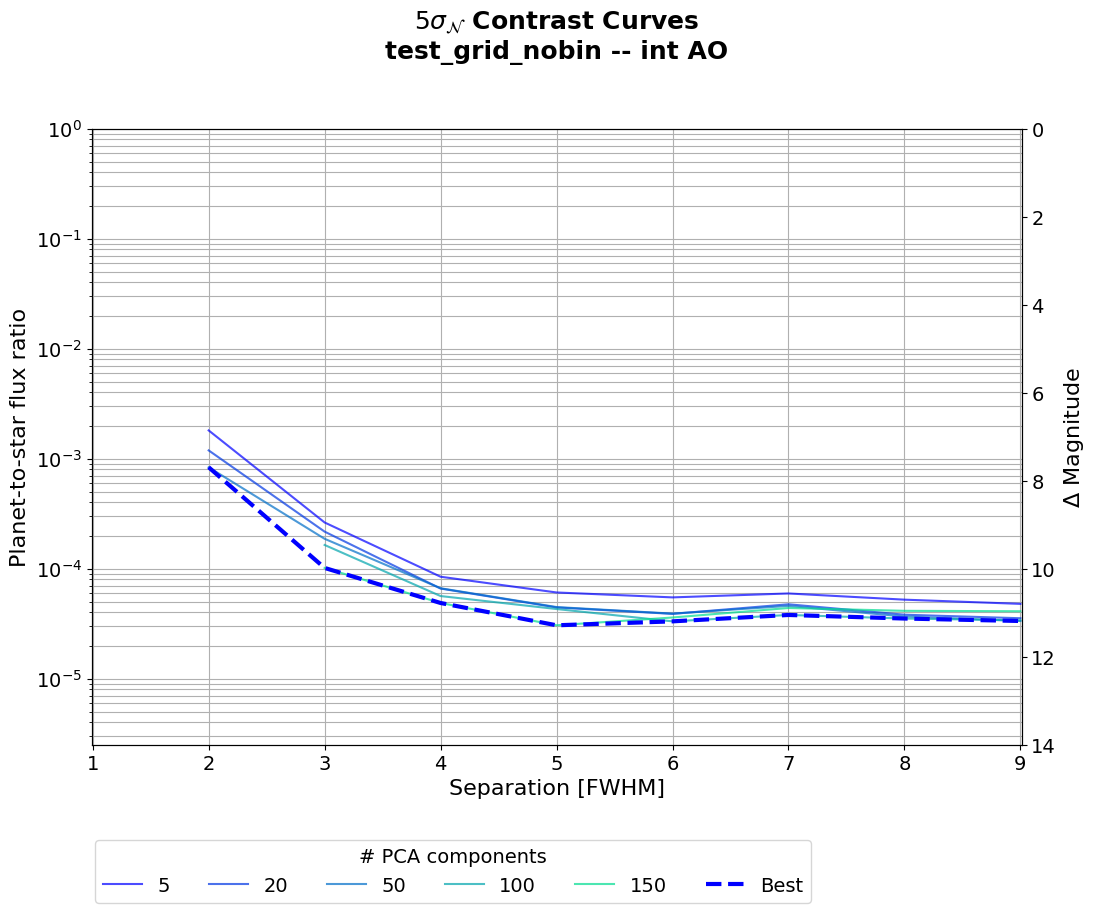

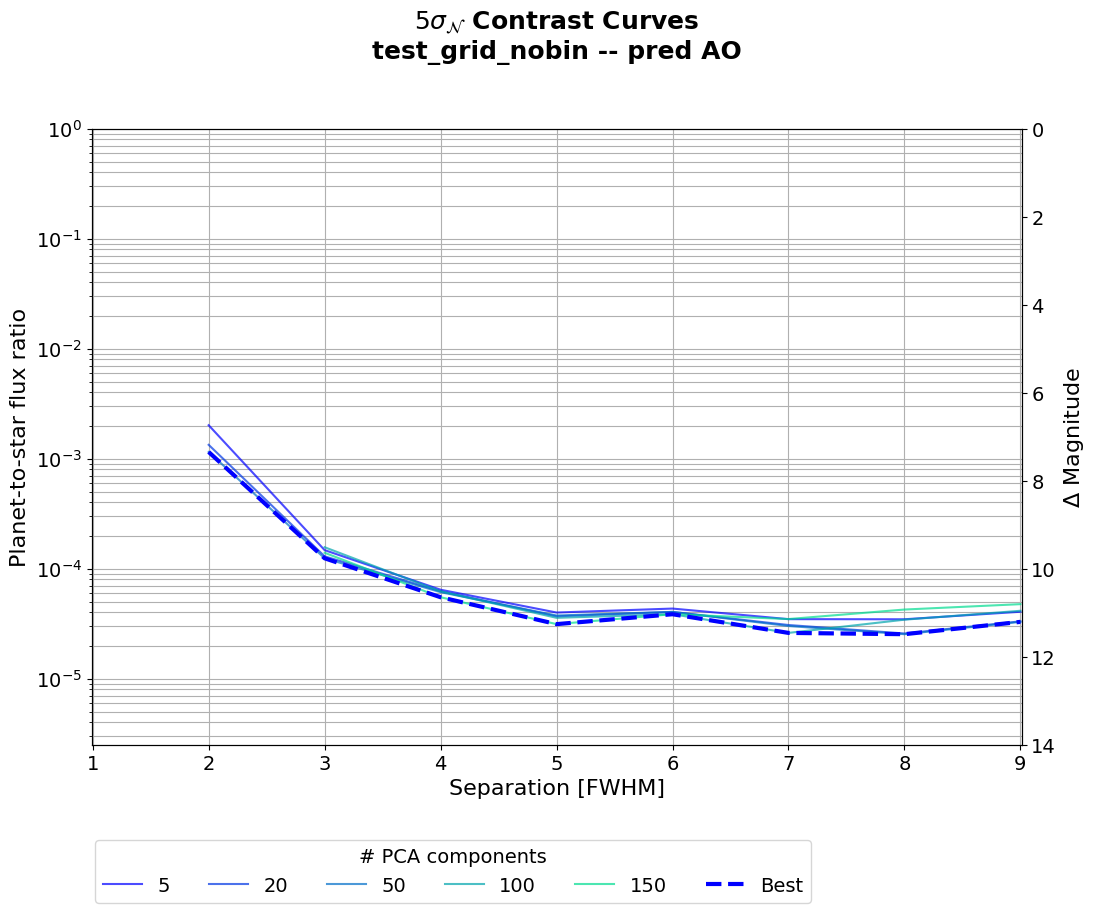

In [12]:
# MAKE PLOTS
#curves_output_path = '/home/aosimul/noah/src/pipeline_ADI/results/contrast/pipeline_ADI_gram'
rangey      = (14, 0)
for algo_name, device in algorithms.items():
    for dataset_name, dataset in datasets.items():
        plot_contrast_curves2(test_grid[(dataset_name,  algo_name)][0], rangey, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name} AO"))
        plt.savefig(f'{curves_output_path}/{name}_{dataset_name}_{algo_name}.png', bbox_inches="tight", pad_inches=0.15)

In [26]:
folder = '/home/aosimul/noah/results/contrast_grid/'
components              = [20, 100] 

for algo_name, device in algorithms.items():
    for dataset_name in ['int']:
        folder = f'/home/aosimul/noah/results/contrast_grid/{name}_{dataset_name}_{algo_name}'

        # create_pca_gif(
        #     folder,
        #     components,
        #     output_gif=f"/home/aosimul/noah/results/animations/pca_test_grid_lr_{dataset_name}.gif",
        #     duration=0.5)
        
        #folder = f'/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/pipeline_ADI_{dataset_name}_PCAD'

        create_pca_gif(
            folder,
            components if algo_name =='PCAD' else None,
            output_gif=f"/home/aosimul/noah/results/animations/pca_{name}_{dataset_name}_{algo_name}.gif",
            duration=0.5)

Saved GIF: /home/aosimul/noah/results/animations/pca_test_grid_int_PCAD.gif
Saved GIF: /home/aosimul/noah/results/animations/pca_test_grid_int_CADI.gif
